In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

In [10]:
cdf = pd.read_csv('chess_games.csv')
cdf.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1504210000000,1504210000000,13.0,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1504130000000,1504130000000,16.0,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1504130000000,1504130000000,61.0,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1504110000000,1504110000000,61.0,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1504030000000,1504030000000,95.0,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [14]:
cdf.rename(columns = {'id':'game_id','rated':'game_is_rated','created_at':'start_time','last_move_at':'end_time','turns':'number_of_moves',
                       'victory_status':'game_outcome','winner':'winner','increment_code':'time_increment','white_id':'white_piece_player_id','white_rating':'white_piece_player_rating',
                      'black_id':'black_piece_player_id','black_rating':'black_piece_player_rating','moves':'all_moves_in_standard_chess_notation','opening_eco':'standardised_code_for_any_given_opening_moves',
                      'opening_name':'opening_moves_name','opening_ply':'number_of_moves_in_the_opening_phase'},inplace=True)
cdf.columns

Index(['game_id', 'game_is_rated', 'start_time', 'end_time', 'number_of_moves',
       'game_outcome', 'winner', 'time_increment', 'white_piece_player_id',
       'white_piece_player_rating', 'black_piece_player_id',
       'black_piece_player_rating', 'all_moves_in_standard_chess_notation',
       'standardised_code_for_any_given_opening_moves', 'opening_moves_name',
       'number_of_moves_in_the_opening_phase'],
      dtype='str')

In [16]:
cdf.head(20)

,game_id,game_is_rated,start_time,end_time,number_of_moves,game_outcome,winner,time_increment,white_piece_player_id,white_piece_player_rating,black_piece_player_id,black_piece_player_rating,all_moves_in_standard_chess_notation,standardised_code_for_any_given_opening_moves,opening_moves_name,number_of_moves_in_the_opening_phase
0,TZJHLljE,False,1504210000000,1504210000000,13.0,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1504130000000,1504130000000,16.0,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1504130000000,1504130000000,61.0,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1504110000000,1504110000000,61.0,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1504030000000,1504030000000,95.0,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5
5,MsoDV9wj,False,1504240000000,1504240000000,5.0,draw,draw,10+0,trelynn17,1250,franklin14532,1002,e4 c5 Nf3 Qa5 a3,B27,Sicilian Defense: Mongoose Variation,4
6,qwU9rasv,True,1504230000000,1504230000000,33.0,resign,white,10+0,capa_jr,1520,daniel_likes_chess,1423,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Nc6 Bb5 a6 ...,D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10
7,RVN0N3VK,False,1503680000000,1503680000000,9.0,resign,black,15+30,daniel_likes_chess,1413,soultego,2108,e4 Nc6 d4 e5 d5 Nce7 c3 Ng6 b4,B00,Nimzowitsch Defense: Kennedy Variation | Link...,5
8,dwF3DJHO,True,1503510000000,1503510000000,66.0,resign,black,15+0,ehabfanri,1439,daniel_likes_chess,1392,e4 e5 Bc4 Nc6 Nf3 Nd4 d3 Nxf3+ Qxf3 Nf6 h3 Bc5...,C50,Italian Game: Schilling-Kostic Gambit,6
9,afoMwnLg,True,1503440000000,1503440000000,119.0,mate,white,10+0,daniel_likes_chess,1381,mirco25,1209,e4 d5 exd5 Qxd5 Nc3 Qe5+ Be2 Na6 d4 Qf5 Bxa6 b...,B01,Scandinavian Defense: Mieses-Kotroc Variation,4


In [17]:
cdf.describe(include='all')

,game_id,game_is_rated,start_time,end_time,number_of_moves,game_outcome,winner,time_increment,white_piece_player_id,white_piece_player_rating,black_piece_player_id,black_piece_player_rating,all_moves_in_standard_chess_notation,standardised_code_for_any_given_opening_moves,opening_moves_name,number_of_moves_in_the_opening_phase
count,20058,20058,2.005800e+04,2.005800e+04,19931.000000,20058,20058,20058,20058,20058.000000,20058,20058.000000,20058,20058,20058,20058.000000
unique,19113,2,NaN,NaN,NaN,4,3,400,9438,NaN,9331,NaN,18920,365,1477,NaN
top,XRuQPSzH,True,NaN,NaN,NaN,resign,white,10+0,taranga,NaN,taranga,NaN,e4 e5,A00,Van't Kruijs Opening,NaN
freq,5,16155,NaN,NaN,NaN,11147,10001,7721,72,NaN,82,NaN,27,1007,368,NaN
mean,NaN,NaN,1.483617e+12,1.483618e+12,60.481361,NaN,NaN,NaN,NaN,1596.631868,NaN,1588.831987,NaN,NaN,NaN,4.816981
std,NaN,NaN,2.850151e+10,2.850140e+10,33.575359,NaN,NaN,NaN,NaN,291.253376,NaN,291.036126,NaN,NaN,NaN,2.797152
min,NaN,NaN,1.376772e+12,1.376772e+12,1.000000,NaN,NaN,NaN,NaN,784.000000,NaN,789.000000,NaN,NaN,NaN,1.000000
25%,NaN,NaN,1.477548e+12,1.477548e+12,37.000000,NaN,NaN,NaN,NaN,1398.000000,NaN,1391.000000,NaN,NaN,NaN,3.000000
50%,NaN,NaN,1.496010e+12,1.496010e+12,55.000000,NaN,NaN,NaN,NaN,1567.000000,NaN,1562.000000,NaN,NaN,NaN,4.000000
75%,NaN,NaN,1.503170e+12,1.503170e+12,79.000000,NaN,NaN,NaN,NaN,1793.000000,NaN,1784.000000,NaN,NaN,NaN,6.000000


In [18]:
cdf.dtypes

game_id                                              str
game_is_rated                                       bool
start_time                                         int64
end_time                                           int64
number_of_moves                                  float64
game_outcome                                         str
winner                                               str
time_increment                                       str
white_piece_player_id                                str
white_piece_player_rating                          int64
black_piece_player_id                                str
black_piece_player_rating                          int64
all_moves_in_standard_chess_notation                 str
standardised_code_for_any_given_opening_moves        str
opening_moves_name                                   str
number_of_moves_in_the_opening_phase               int64
dtype: object

In [19]:
cdf.shape

(20058, 16)

In [20]:
print(f"number of elements:{cdf.shape[0] * cdf.shape[1]} ")

number of elements:320928 


In [37]:
all_ratings = pd.concat( [cdf['white_piece_player_rating'],cdf['black_piece_player_rating']], axis=1)

all_ratings.max()


white_piece_player_rating    2700
black_piece_player_rating    2723
dtype: int64

In [36]:
all_ratings.min()

white_piece_player_rating    784
black_piece_player_rating    789
dtype: int64

In [41]:
cdf[(cdf.black_piece_player_rating== 2723)]['black_piece_player_id']

4473    justicebot
Name: black_piece_player_id, dtype: str

In [42]:
cdf[(cdf.white_piece_player_rating== 784)]['white_piece_player_id']

1655     ragnarlothbrook_spb
11466        crazyscientist1
Name: white_piece_player_id, dtype: str

In [45]:
cdf.value_counts('game_outcome')

game_outcome
resign       11147
mate          6325
outoftime     1680
draw           906
Name: count, dtype: int64

In [50]:
(cdf.value_counts('game_outcome',normalize=True)*100).round(2)
all_games= cdf.value_counts('game_outcome')

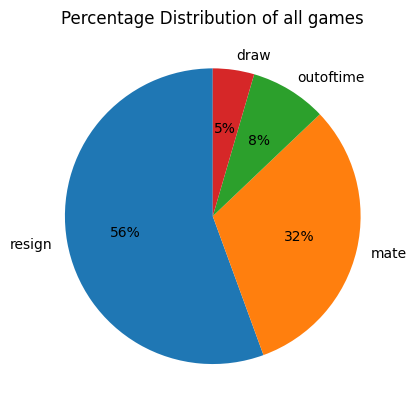

In [54]:
plt.pie(all_games.to_list(),labels=all_games.index,autopct = '%.0f%%', startangle=90)
plt.title('Percentage Distribution of all games')
plt.show()

,game_id,game_is_rated,start_time,end_time,number_of_moves,game_outcome,winner,time_increment,white_piece_player_id,white_piece_player_rating,black_piece_player_id,black_piece_player_rating,all_moves_in_standard_chess_notation,standardised_code_for_any_given_opening_moves,opening_moves_name,number_of_moves_in_the_opening_phase
0,TZJHLljE,False,1504210000000,1504210000000,13.0,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
2,mIICvQHh,True,1504130000000,1504130000000,61.0,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1504110000000,1504110000000,61.0,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1504030000000,1504030000000,95.0,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5
6,qwU9rasv,True,1504230000000,1504230000000,33.0,resign,white,10+0,capa_jr,1520,daniel_likes_chess,1423,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Nc6 Bb5 a6 ...,D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20050,nYOvevdh,True,1499814002224,1499814052544,9.0,outoftime,white,10+0,jamboger,1243,yamaguchipolgar,1142,c4 e5 d4 exd4 Qxd4 Nf6 Bg5 Be7 e4,A20,English Opening: King's English Variation,2
20052,EopEqqAa,True,1499811847779,1499812436546,37.0,resign,white,10+10,jamboger,1219,samael88,1250,c4 e6 d4 b6 Nc3 Bb7 Nf3 g6 h4 Bg7 Bg5 f6 Bf4 d...,A40,English Defense,4
20053,EfqH7VVH,True,1499790914342,1499791236076,24.0,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2
20055,yrAas0Kj,True,1499697877493,1499698050327,35.0,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3


In [65]:
def get_winner_id(row):
    if row['winner']=='white':
        return row['white_piece_player_id']
    elif row['winner']=='black':
        return row['white_piece_player_id']
    else:
        return None

cdf['winner_id']= cdf.apply(get_winner_id,axis=1)

win_counts= cdf['winner_id'].value_counts()
win_counts.idxmax()

'taranga'

In [68]:
white_losses = cdf[(cdf.winner == 'black')]

white_resigned_count = len( white_losses[cdf.game_outcome == 'resign'])

total_white_losses = len(white_losses)

percentage = (white_resigned_count/total_white_losses) * 100
print(round(percentage,2))

58.23


C:\Users\mnqob\AppData\Local\Temp\ipykernel_9504\4007200675.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  white_resigned_count = len( white_losses[cdf.game_outcome == 'resign'])


In [70]:
cdf[(cdf.game_outcome == 'draw')]['number_of_moves'].mean()

np.float64(83.95089285714286)

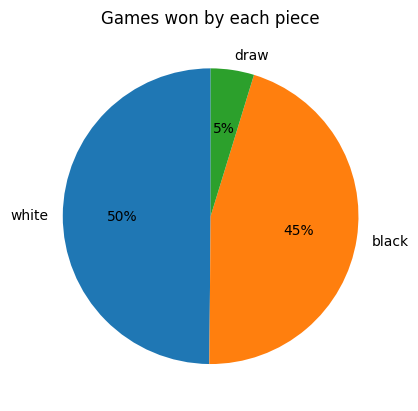

In [75]:
result_counts = cdf['winner'].value_counts()

plt.title('Games won by each piece')
plt.pie(result_counts, labels = result_counts.index , autopct = '%.0f%%', startangle=90 )
plt.show()

I recommend against forcing the dataset to be perfectly balanced. The current distribution reflects the natural 'Ground Truth' of chess, including the inherent first-move advantage for White. Artificially balancing the data would result in a loss of valuable information and provide a skewed representation of player behavior and game outcomes. Instead, we should use evaluation metrics that account for imbalance, such as an F1-score or a Confusion Matrix, rather than changing the data itself

Recommendation: Undersampling
Reason: Undersampling is preferred here because it ensures that the model only trains on 
authentic, real-world chess matches. Oversampling would require creating synthetic 
data points which may not follow the logical rules of chess or realistic player 
behavior. By undersampling the majority classes (White/Black wins), we maintain the 
integrity of the features like 'opening_moves_name' and 'player_rating' while 
achieving the requested balance.


In [91]:
cdf.isnull().sum()

game_id                                            0
game_is_rated                                      0
start_time                                         0
end_time                                           0
number_of_moves                                  127
game_outcome                                       0
winner                                             0
time_increment                                     0
white_piece_player_id                              0
white_piece_player_rating                          0
black_piece_player_id                              0
black_piece_player_rating                          0
all_moves_in_standard_chess_notation               0
standardised_code_for_any_given_opening_moves      0
opening_moves_name                                 0
number_of_moves_in_the_opening_phase               0
dtype: int64

In [83]:
cdf['number_of_moves'].fillna( round(cdf['number_of_moves'].mean()) )

cdf.drop(['winner_id'],axis=1,inplace=True)

KeyError: "['winner_id'] not found in axis"

In [97]:
# Check for actual NaNs
null_count = cdf['number_of_moves'].isna().sum()

# Check for empty strings (common in chess datasets)
empty_string_count = (cdf['number_of_moves'] == '').sum()

print(f"Actual NaNs: {null_count}")
print(f"Empty Strings: {empty_string_count}")

Actual NaNs: 127
Empty Strings: 0


In [101]:
# 1. Break the link to the original data (Fixes the ChainedAssignment error for good)
cdf = cdf.copy()

# 2. Convert the column to numeric, forcing anything weird (strings, spaces) to NaN
cdf['number_of_moves'] = pd.to_numeric(cdf['number_of_moves'], errors='coerce')

# 3. Calculate mean and fill using .loc (the 'correct' way to modify a dataframe)
avg_moves = round(cdf['number_of_moves'].mean())
cdf.loc[cdf['number_of_moves'].isna(), 'number_of_moves'] = avg_moves

# 4. Final conversion to integer
cdf['number_of_moves'] = cdf['number_of_moves'].astype(int)

# CHECK THE OUTPUT
print(cdf['number_of_moves'].isnull().sum())

0


In [102]:
cdf.drop(['game_id', 'time_increment', 'all_moves_in_standard_chess_notation','opening_moves_name'],axis=1,inplace=True)

cdf.head()

,game_is_rated,start_time,end_time,number_of_moves,game_outcome,winner,white_piece_player_id,white_piece_player_rating,black_piece_player_id,black_piece_player_rating,standardised_code_for_any_given_opening_moves,number_of_moves_in_the_opening_phase
0,False,1504210000000,1504210000000,13,outoftime,white,bourgris,1500,a-00,1191,D10,5
1,True,1504130000000,1504130000000,16,resign,black,a-00,1322,skinnerua,1261,B00,4
2,True,1504130000000,1504130000000,61,mate,white,ischia,1496,a-00,1500,C20,3
3,True,1504110000000,1504110000000,61,mate,white,daniamurashov,1439,adivanov2009,1454,D02,3
4,True,1504030000000,1504030000000,95,mate,white,nik221107,1523,adivanov2009,1469,C41,5


In [105]:
print(f"Game is rated: {cdf['game_is_rated'].unique()}\n")
print(f"Game outcome: {cdf['game_outcome'].unique()}\n")
print(f"Game outcome: {cdf['winner'].unique()}\n")
print(f"White piece player id: {cdf['white_piece_player_id'].unique()}\n")
print(f"Black piece player id: {cdf['black_piece_player_id'].unique()}\n")

Game is rated: [False  True]

Game outcome: <StringArray>
['outoftime', 'resign', 'mate', 'draw']
Length: 4, dtype: str

Game outcome: <StringArray>
['white', 'black', 'draw']
Length: 3, dtype: str

White piece player id: <StringArray>
[          'bourgris',               'a-00',             'ischia',
      'daniamurashov',          'nik221107',          'trelynn17',
            'capa_jr', 'daniel_likes_chess',          'ehabfanri',
  'shivangithegenius',
 ...
         'kaashish27',       'egor_antonov',           'oddskill',
       'kevineclmans',          'shchuchin',      'mateuslichess',
            'jkubb29',           'samael88',            'belcolt',
       'marcodisogno']
Length: 9438, dtype: str

Black piece player id: <StringArray>
[              'a-00',          'skinnerua',       'adivanov2009',
      'franklin14532', 'daniel_likes_chess',           'soultego',
            'mirco25',           'anaissac',          'subham777',
      'roman12342005',
 ...
              'mhm9

In [ ]:
label_encoder = LablEncoder()
Black piece player id
cdf['game_is_rated'] = label_encoder.fit_transform(cdf['game_is_rated'])
cdf['winner'] = label_encoder.fit_transform(cdf['game_is_rated'])